In [1]:
!pip install pyspark

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/02 04:00:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
from pyspark.sql.functions import col, length, when
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, Imputer
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import count, avg, min, max
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests
import pandas as pd
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, PCA
import numpy as np
from sklearn.metrics import confusion_matrix

In [4]:
df = spark.read.csv("/expanse/lustre/projects/uci157/zalabadleh/AmazonReviews/*.tsv", sep="\t", header=True, inferSchema=True)
df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: string (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)



In [5]:
df.count()

58075027

In [6]:
df.describe().show()

26/06/02 04:01:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------+--------------------+--------------+-------------------+--------------------+--------------------+----------------+-----------------+------------------+------------------+--------+-----------------+--------------------+--------------------+
|summary|marketplace|         customer_id|     review_id|         product_id|      product_parent|       product_title|product_category|      star_rating|     helpful_votes|       total_votes|    vine|verified_purchase|     review_headline|         review_body|
+-------+-----------+--------------------+--------------+-------------------+--------------------+--------------------+----------------+-----------------+------------------+------------------+--------+-----------------+--------------------+--------------------+
|  count|   58075027|            58075027|      58075026|           58075026|            58075026|            58075025|        58073944|         58073934|          58073928|          58073928|58073928|         5807

In [7]:
from pyspark.sql.functions import count, avg, min, max
>>> df.groupBy("product_category") \
      .agg(
          count("*").alias("num_reviews"),
          avg("star_rating").alias("avg_rating"),
          avg("helpful_votes").alias("avg_helpful_votes")
) \
.orderBy("num_reviews", ascending=False) \
.show(10)

+----------------+-----------+------------------+------------------+
|product_category|num_reviews|        avg_rating| avg_helpful_votes|
+----------------+-----------+------------------+------------------+
|        Wireless|    7266941|   3.9254046510079|0.6362107522271063|
|              PC|    6283460|4.1024690218446525|1.1721180687073682|
|            Toys|    4864293|4.2117329280945865| 1.477076730369655|
|          Sports|    4849563| 4.229311795722625| 1.473776296957066|
|       Video DVD|    4690455| 4.328275401853339|2.6382939395005387|
|           Shoes|    4366916| 4.241260422687315|0.8771812876638799|
|    Pet Products|    2643614| 4.143652969003796|1.6528846495744083|
| Office Products|    2642409| 4.072544030844582|1.9013086164935102|
|        Outdoors|    2302392| 4.240021681798756|  1.84732530342357|
|     Video Games|    1786145|4.0599313045693375| 2.260269463005523|
+----------------+-----------+------------------+------------------+
only showing top 10 rows



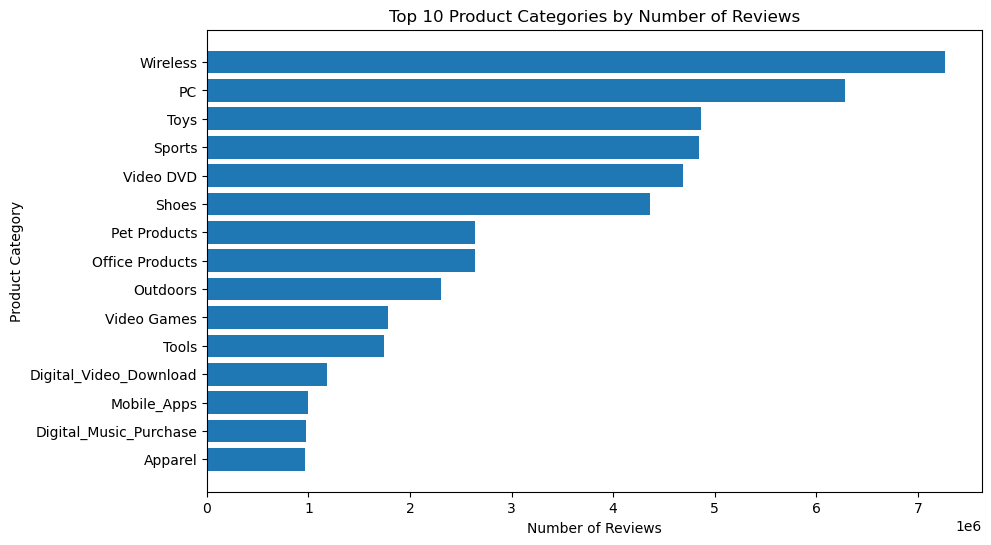

In [8]:
top_categories = df.filter(col("product_category").isNotNull()) \
    .groupBy("product_category") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(15)

pdf = top_categories.toPandas()
plt.figure(figsize=(10,6))                                                                                           
plt.barh(pdf["product_category"], pdf["count"])
plt.title("Top 10 Product Categories by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.show()


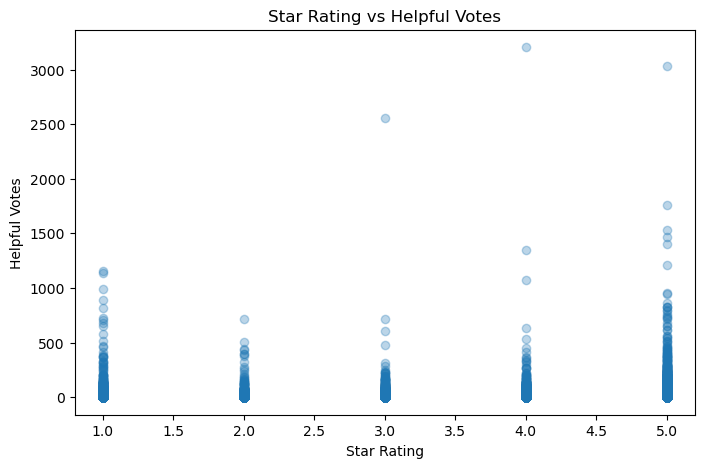

In [9]:
scatter_df = df.select("star_rating", "helpful_votes") \
    .filter(col("star_rating").isNotNull()) \
    .filter(col("helpful_votes").isNotNull()) \
    .sample(0.01)

pdf = scatter_df.toPandas()
plt.figure(figsize=(8,5))
plt.scatter(
    pdf["star_rating"].astype(float),
    pdf["helpful_votes"],
    alpha=0.3
)

plt.title("Star Rating vs Helpful Votes")
plt.xlabel("Star Rating")
plt.ylabel("Helpful Votes")
plt.show()

In [10]:
#Get the active Spark Context and URL
sc = spark.sparkContext

url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

#Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

#Format into a readable DataFrame
executor_df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
executor_df['maxMemory_GB'] = (executor_df['maxMemory'] / (1024**3)).round(2)
executor_df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,12,455501414,0,True,0.42


In [11]:
df.select(
    "star_rating",
    "helpful_votes",
    "total_votes",
    "verified_purchase",
    "product_category",
    "review_body"
).where(
    col("star_rating").isNull() |
    col("helpful_votes").isNull() |
    col("total_votes").isNull() |
    col("verified_purchase").isNull() |
    col("product_category").isNull() |
    col("review_body").isNull()
).count()   ## checking the count for null values

8492

In [12]:
df_clean = df.dropna(subset=[
    "verified_purchase",
    "product_category",
    "review_body",
    "star_rating",
    "total_votes",
    "helpful_votes"
])
df_clean = df_clean.withColumn("star_rating", col("star_rating").cast("double"))
df_clean = df_clean.withColumn("total_votes", col("total_votes").cast("double"))
df_clean = df_clean.withColumn("helpful_votes", col("helpful_votes").cast("double"))
df_features = df_clean.withColumn(
    "review_length",
    length(col("review_body"))
)
df_features = df_features.withColumn(
    "helpful_label",
    when(col("helpful_votes") > 0, 1).otherwise(0)
)

In [13]:
tokenizer = Tokenizer(
    inputCol="review_body",
    outputCol="words"
)
##splits the review body into individual words
remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="raw_text_features",
    numFeatures=500
)
##turns wors into number values with 500 spaces, we can move it up if needed in the expanse
idf = IDF(
    inputCol="raw_text_features",
    outputCol="tfidf_features"
)
#checks how meaningful each of the 500 words are
pca = PCA(
    k=80,
    inputCol="tfidf_features",
    outputCol="pca_features"
)
#based on the scores from the idf pca reduces to 50 based on significance

dt_pca = DecisionTreeClassifier(
    labelCol="helpful_label",
    featuresCol="pca_features",
    maxDepth=5
)

pipeline_pca_dt = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    idf,
    pca,
    dt_pca
])

#Random Forest
rf_pca = RandomForestClassifier(
    labelCol="helpful_label",
    featuresCol="pca_features",
    numTrees=20
)

pipeline_pca_rf = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    idf,
    pca,
    rf_pca
])


In [14]:
# Evaluation

In [15]:
df_sample = df_features.sample(fraction=0.01, seed=42)

In [16]:
train_data, test_data = df_sample.randomSplit([0.8, 0.2], seed=42)
pca_dt_model = pipeline_pca_dt.fit(train_data) 

In [17]:
#Predictions 
train_pred_pca = pca_dt_model.transform(train_data)
test_pred_pca = pca_dt_model.transform(test_data)

In [18]:
#Evaluation
train_pred_pca.select("helpful_label", "prediction").show(10)
test_pred_pca.select("helpful_label", "prediction").show(10)

+-------------+----------+
|helpful_label|prediction|
+-------------+----------+
|            1|       1.0|
|            0|       0.0|
|            1|       1.0|
|            1|       1.0|
|            1|       1.0|
|            0|       0.0|
|            1|       1.0|
|            0|       1.0|
|            0|       0.0|
|            0|       0.0|
+-------------+----------+
only showing top 10 rows



+-------------+----------+
|helpful_label|prediction|
+-------------+----------+
|            1|       0.0|
|            1|       1.0|
|            1|       1.0|
|            1|       0.0|
|            0|       0.0|
|            0|       0.0|
|            0|       1.0|
|            0|       1.0|
|            1|       1.0|
|            1|       0.0|
+-------------+----------+
only showing top 10 rows



In [19]:
test_pred_pca.select(
    "helpful_label",
    "prediction"
).show(10)

+-------------+----------+
|helpful_label|prediction|
+-------------+----------+
|            1|       0.0|
|            1|       1.0|
|            1|       1.0|
|            1|       0.0|
|            0|       0.0|
|            0|       0.0|
|            0|       1.0|
|            0|       1.0|
|            1|       1.0|
|            1|       0.0|
+-------------+----------+
only showing top 10 rows



In [20]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="helpful_label",
    predictionCol="prediction",
    metricName="accuracy"
)
train_acc_pca = evaluator.evaluate(train_pred_pca)
test_acc_pca = evaluator.evaluate(test_pred_pca)
print(" Training Accuracy:", train_acc_pca)
print("Test Accuracy:", test_acc_pca)
print(" Training Error:", 1 - train_acc_pca)
print(" Test Error:", 1 - test_acc_pca)

 Training Accuracy: 0.7468764799586688
Test Accuracy: 0.7480694315165305
 Training Error: 0.2531235200413312
 Test Error: 0.2519305684834695


In [21]:
pca_model = pca_dt_model.stages[4]

print(pca_model.explainedVariance)
print("Total explained variance:", sum(pca_model.explainedVariance))

[0.16120257044206524,0.03699819321392387,0.017458647329490845,0.009653709253064198,0.007838845327132728,0.007012102931550334,0.00645710978827854,0.005937259844852337,0.00588502129796586,0.00425089701431075,0.003859971380379806,0.0037600303487255126,0.00363329735322208,0.0034631171487052755,0.003324061532972922,0.0032919003867443006,0.0032075480067691904,0.003064121769324172,0.003037212543844301,0.0029834778641949114,0.002911929681303652,0.0028223106767024126,0.0028028829119760997,0.0027312785317808357,0.0027088702962600893,0.0026885352575223365,0.0026621018406272575,0.0025971750305262293,0.00257707694002878,0.0025626568010416557,0.002513856678474403,0.0024658011808558027,0.0024269977506157065,0.002424255521669906,0.002403341194233118,0.002378451355897132,0.0023586484683680827,0.0023526262967730658,0.0023451795232860857,0.002322011500176824,0.002294882770744937,0.0022863532640558857,0.0022528040444739317,0.002248421001168257,0.002230928827558043,0.00221140002316652,0.002194560882190917,

In [22]:
#Different model with different hyperparameters
rf = RandomForestClassifier(
    labelCol="helpful_label",
    featuresCol="pca_features",
    numTrees=20
)

pipeline_rf = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    idf,
    pca,
    rf
])

rf_model = pipeline_rf.fit(train_data)

In [23]:
#Predictions
train_pred_rf = rf_model.transform(train_data)
test_pred_rf = rf_model.transform(test_data)

In [24]:
#Evaluation
train_pred_rf.select("helpful_label", "prediction").show(10)
test_pred_rf.select("helpful_label", "prediction").show(10)

+-------------+----------+
|helpful_label|prediction|
+-------------+----------+
|            1|       1.0|
|            0|       0.0|
|            1|       1.0|
|            1|       1.0|
|            1|       1.0|
|            0|       0.0|
|            1|       1.0|
|            0|       1.0|
|            0|       1.0|
|            0|       1.0|
+-------------+----------+
only showing top 10 rows

+-------------+----------+
|helpful_label|prediction|
+-------------+----------+
|            1|       0.0|
|            1|       1.0|
|            1|       1.0|
|            1|       0.0|
|            0|       1.0|
|            0|       0.0|
|            0|       1.0|
|            0|       1.0|
|            1|       1.0|
|            1|       0.0|
+-------------+----------+
only showing top 10 rows



In [25]:
test_pred_rf.select(
    "helpful_label",
    "prediction"
).show(10)

+-------------+----------+
|helpful_label|prediction|
+-------------+----------+
|            1|       0.0|
|            1|       1.0|
|            1|       1.0|
|            1|       0.0|
|            0|       1.0|
|            0|       0.0|
|            0|       1.0|
|            0|       1.0|
|            1|       1.0|
|            1|       0.0|
+-------------+----------+
only showing top 10 rows



In [26]:
#Evaluation 
train_acc_rf = evaluator.evaluate(train_pred_rf)
test_acc_rf = evaluator.evaluate(test_pred_rf)

print("Random Forest")
print(" Training Accuracy:", train_acc_rf)
print("Test Accuracy:", test_acc_rf)
print(" Training Error:", 1 - train_acc_rf)
print(" Test Error:", 1 - test_acc_rf)

Random Forest
 Training Accuracy: 0.7420588108666638
Test Accuracy: 0.7428637914986038
 Training Error: 0.2579411891333362
 Test Error: 0.2571362085013962


In [27]:
#Predictions Analysis 

test_predictions = pca_dt_model.transform(test_data)

prediction_analysis = test_predictions.withColumn(
    "result_type",
    when(
        (col("helpful_label") == 1) & (col("prediction") == 1),
        "Correct"
    ).when(
        (col("helpful_label") == 0) & (col("prediction") == 0),
        "Correct"
    ).when(
        (col("helpful_label") == 0) & (col("prediction") == 1),
        "False Positive"
    ).when(
        (col("helpful_label") == 1) & (col("prediction") == 0),
        "False Negative"
    )
)

prediction_analysis.select(
    "helpful_label",
    "prediction",
    "probability",
    "result_type"
).show(15, truncate=False)

+-------------+----------+----------------------------------------+--------------+
|helpful_label|prediction|probability                             |result_type   |
+-------------+----------+----------------------------------------+--------------+
|1            |0.0       |[0.7981671855724608,0.20183281442753923]|False Negative|
|1            |1.0       |[0.3087504686914136,0.6912495313085865] |Correct       |
|1            |1.0       |[0.3087504686914136,0.6912495313085865] |Correct       |
|1            |0.0       |[0.7981671855724608,0.20183281442753923]|False Negative|
|0            |0.0       |[0.5594723099107526,0.4405276900892474] |Correct       |
|0            |0.0       |[0.7981671855724608,0.20183281442753923]|Correct       |
|0            |1.0       |[0.4127280265339967,0.5872719734660033] |False Positive|
|0            |1.0       |[0.3087504686914136,0.6912495313085865] |False Positive|
|1            |1.0       |[0.3087504686914136,0.6912495313085865] |Correct       |
|1  

In [28]:
#RESULTS SECION

In [29]:
df_features.select("review_length", "helpful_label").show(10)

+-------------+-------------+
|review_length|helpful_label|
+-------------+-------------+
|          273|            0|
|          272|            0|
|          410|            1|
|          211|            0|
|          100|            0|
|          258|            0|
|          196|            0|
|          126|            1|
|          109|            0|
|          331|            0|
+-------------+-------------+
only showing top 10 rows



In [30]:
#Results: TF-IDF + PCA + Decision Tree 

In [31]:
#Accuracy
print("Decision Tree Training Accuracy:", train_acc_pca)
print("Decision Tree Test Accuracy:", test_acc_pca)

Decision Tree Training Accuracy: 0.7468764799586688
Decision Tree Test Accuracy: 0.7480694315165305


In [32]:
#Error Scores
print("Training Error:", 1 - train_acc_pca)
print("Test Error:", 1 - test_acc_pca)

Training Error: 0.2531235200413312
Test Error: 0.2519305684834695


In [33]:
#Model Structure
print(pca_dt_model.stages[-1].toDebugString)

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_7aef80db3298, depth=5, numNodes=15, numClasses=2, numFeatures=80
  If (feature 0 <= -3.8844355762673803)
   If (feature 0 <= -9.510332738564994)
    Predict: 1.0
   Else (feature 0 > -9.510332738564994)
    If (feature 0 <= -6.50376130550832)
     If (feature 6 <= -0.21715877931166577)
      If (feature 10 <= -1.5131025037542365)
       Predict: 0.0
      Else (feature 10 > -1.5131025037542365)
       Predict: 1.0
     Else (feature 6 > -0.21715877931166577)
      Predict: 1.0
    Else (feature 0 > -6.50376130550832)
     If (feature 10 <= -2.494932712222725)
      If (feature 8 <= -1.6837314267111243)
       Predict: 1.0
      Else (feature 8 > -1.6837314267111243)
       Predict: 0.0
     Else (feature 10 > -2.494932712222725)
      Predict: 0.0
  Else (feature 0 > -3.8844355762673803)
   Predict: 0.0



In [34]:
#PCA Variance 
print(pca_model.explainedVariance)
print("Total explained variance:", sum(pca_model.explainedVariance))

[0.16120257044206524,0.03699819321392387,0.017458647329490845,0.009653709253064198,0.007838845327132728,0.007012102931550334,0.00645710978827854,0.005937259844852337,0.00588502129796586,0.00425089701431075,0.003859971380379806,0.0037600303487255126,0.00363329735322208,0.0034631171487052755,0.003324061532972922,0.0032919003867443006,0.0032075480067691904,0.003064121769324172,0.003037212543844301,0.0029834778641949114,0.002911929681303652,0.0028223106767024126,0.0028028829119760997,0.0027312785317808357,0.0027088702962600893,0.0026885352575223365,0.0026621018406272575,0.0025971750305262293,0.00257707694002878,0.0025626568010416557,0.002513856678474403,0.0024658011808558027,0.0024269977506157065,0.002424255521669906,0.002403341194233118,0.002378451355897132,0.0023586484683680827,0.0023526262967730658,0.0023451795232860857,0.002322011500176824,0.002294882770744937,0.0022863532640558857,0.0022528040444739317,0.002248421001168257,0.002230928827558043,0.00221140002316652,0.002194560882190917,

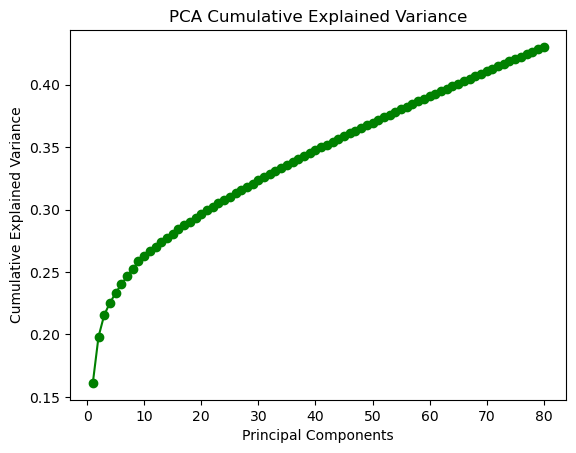

Total explained variance: 0.43017677689483536


In [35]:
#PCA Variance Plot

explained_variance = list(pca_model.explainedVariance)

components = np.arange(1, len(explained_variance) + 1)
cumulative = np.cumsum(explained_variance)

plt.figure()
plt.plot(components, cumulative, marker='o', color='green')
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.savefig("PCA Variance Plot.png", dpi=300, bbox_inches='tight')
plt.show()
print("Total explained variance:", sum(explained_variance))

In [36]:
#Results: TF-IDF + PCA + Random Forest

In [37]:
#Accuracy 
print("Random Forest Training Accuracy:", train_acc_rf)
print("Random Forest Test Accuracy:", test_acc_rf)

Random Forest Training Accuracy: 0.7420588108666638
Random Forest Test Accuracy: 0.7428637914986038


In [38]:
#Error Scores
print("Training Error:", 1 - train_acc_rf)
print("Test Error:", 1 - test_acc_rf)

Training Error: 0.2579411891333362
Test Error: 0.2571362085013962


In [39]:
#Prediction Outputs

#Decision Tree Predictions:
test_pred_pca.select("helpful_label", "prediction").show(10)

#Random Forest Predictions:
test_pred_rf.select("helpful_label", "prediction").show(10)

+-------------+----------+
|helpful_label|prediction|
+-------------+----------+
|            1|       0.0|
|            1|       1.0|
|            1|       1.0|
|            1|       0.0|
|            0|       0.0|
|            0|       0.0|
|            0|       1.0|
|            0|       1.0|
|            1|       1.0|
|            1|       0.0|
+-------------+----------+
only showing top 10 rows

+-------------+----------+
|helpful_label|prediction|
+-------------+----------+
|            1|       0.0|
|            1|       1.0|
|            1|       1.0|
|            1|       0.0|
|            0|       1.0|
|            0|       0.0|
|            0|       1.0|
|            0|       1.0|
|            1|       1.0|
|            1|       0.0|
+-------------+----------+
only showing top 10 rows



In [40]:
#Prediction Analysis (False Positive / False Negative / Correct)
prediction_analysis.select(
    "helpful_label",
    "prediction",
    "probability",
    "result_type"
).show(15, truncate=False)

+-------------+----------+----------------------------------------+--------------+
|helpful_label|prediction|probability                             |result_type   |
+-------------+----------+----------------------------------------+--------------+
|1            |0.0       |[0.7981671855724608,0.20183281442753923]|False Negative|
|1            |1.0       |[0.3087504686914136,0.6912495313085865] |Correct       |
|1            |1.0       |[0.3087504686914136,0.6912495313085865] |Correct       |
|1            |0.0       |[0.7981671855724608,0.20183281442753923]|False Negative|
|0            |0.0       |[0.5594723099107526,0.4405276900892474] |Correct       |
|0            |0.0       |[0.7981671855724608,0.20183281442753923]|Correct       |
|0            |1.0       |[0.4127280265339967,0.5872719734660033] |False Positive|
|0            |1.0       |[0.3087504686914136,0.6912495313085865] |False Positive|
|1            |1.0       |[0.3087504686914136,0.6912495313085865] |Correct       |
|1  

In [41]:
#Confusion Matrix for Decision Tree
y_true = test_pred_pca.select("helpful_label").toPandas()
y_pred = test_pred_pca.select("prediction").toPandas()

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[75989  5979]
 [23252 10808]]


In [42]:
#Figures

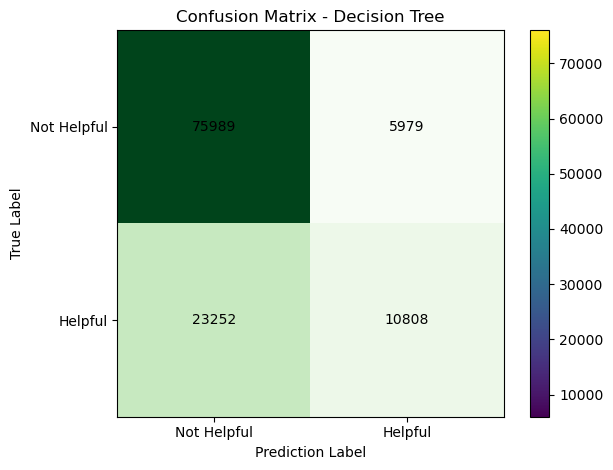

In [43]:
#CM-DT Plot
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Decision Tree")
plt.colorbar()
plt.imshow(cm, cmap="Greens", interpolation="nearest")
           
classes = ["Not Helpful", "Helpful"]
plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

plt.xlabel("Prediction Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")
        
plt.savefig("Confusion Matrix-DT.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [44]:
#Confusion Matrix for Random Forest
y_true_rf = test_pred_rf.select("helpful_label").toPandas()
y_pred_rf = test_pred_rf.select("prediction").toPandas()

cm_rf = confusion_matrix(y_true_rf, y_pred_rf)
print(cm_rf)

[[77404  4564]
 [25271  8789]]


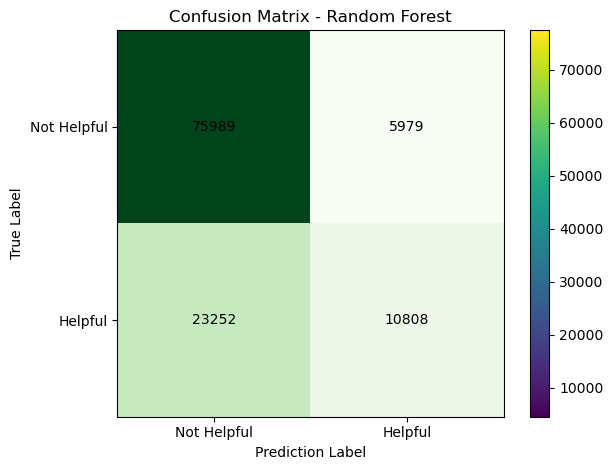

In [45]:
#CM-RM Plot
plt.figure()
plt.imshow(cm_rf, interpolation="nearest")
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.imshow(cm, cmap="Greens", interpolation="nearest")
           
classes = ["Not Helpful", "Helpful"]
plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

plt.xlabel("Prediction Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")
        
plt.savefig("Confusion Matrix-RF.png", dpi=300, bbox_inches='tight')        
plt.tight_layout()
plt.show()

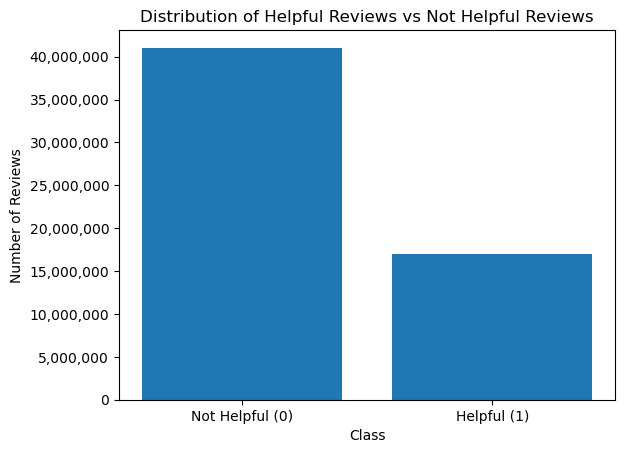

In [46]:
#Distribution of helpful reviews vs not helpful reviews
label_counts = df_features.groupBy("helpful_label").count().orderBy("helpful_label").toPandas()

plt.figure()
plt.bar(label_counts["helpful_label"], label_counts["count"])
plt.xticks([0, 1], ["Not Helpful (0)", "Helpful (1)"])
plt.xlabel("Class")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Helpful Reviews vs Not Helpful Reviews")

plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')
)

plt.savefig("CDistribution of Helpful Reviews vs Not Helpful Reviews.png", dpi=300, bbox_inches='tight')
plt.show()

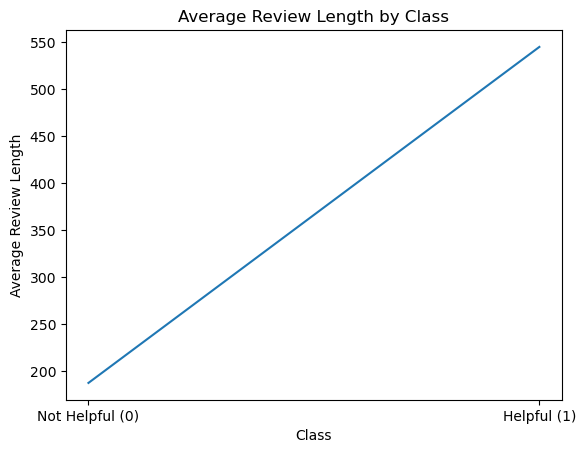

In [50]:
#Average review length per class
length_stats = df_features.groupBy("helpful_label") \
    .avg("review_length") \
    .orderBy("helpful_label") \
    .toPandas()

plt.figure()
plt.plot(length_stats["helpful_label"], length_stats["avg(review_length)"])

plt.xticks([0, 1], ["Not Helpful (0)", "Helpful (1)"])
plt.xlabel("Class")
plt.ylabel("Average Review Length")
plt.title("Average Review Length by Class")

plt.savefig("Average review length per class.png", dpi=300, bbox_inches='tight')
plt.show()

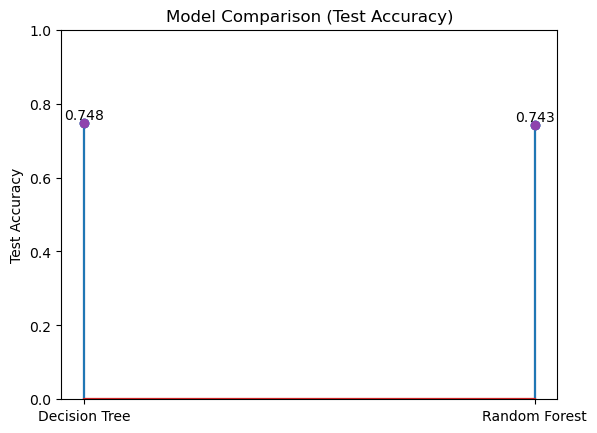

In [51]:
#Model Comparison (Decision Tree vs Random Forest)

models = ["Decision Tree", "Random Forest"]
accuracies = [test_acc_pca, test_acc_rf]

plt.figure()
plt.stem(models, accuracies)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison (Test Accuracy)")    
plt.ylim(0, 1)

plt.setp(plt.stem(models, accuracies)[1], color="#8E44AD")
plt.setp(plt.stem(models, accuracies)[0], markerfacecolor="#8E44AD", markeredgecolor="#8E44AD")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.savefig("Model Comparision.png", dpi=300, bbox_inches='tight')
plt.show()

In [52]:
#Misclassified Examples of FP/FN

misclassified = test_pred_pca.withColumn(
    "result_type",
    when((col("helpful_label") == 1) & (col("prediction") == 0), "False Negative")
    .when((col("helpful_label") == 0) & (col("prediction") == 1), "False Positive")
    .otherwise("Correct")
)

#Samples
misclassified.select(
    "helpful_label",
    "prediction",
    "result_type",
    "review_body"
).show(15, truncate=True)

misclassified.select(
    "helpful_label",
    "prediction",
    "result_type",
    "review_body"
).toPandas().to_csv("misclassified_examples.csv", index=False)

misclassified.groupBy("result_type").count().show()

+-------------+----------+--------------+--------------------+
|helpful_label|prediction|   result_type|         review_body|
+-------------+----------+--------------+--------------------+
|            1|       0.0|False Negative|The best autobrio...|
|            1|       1.0|       Correct|Since this movie ...|
|            1|       1.0|       Correct|Hearing humming a...|
|            1|       0.0|False Negative|This was one of t...|
|            0|       0.0|       Correct|Ifound the book T...|
|            0|       0.0|       Correct|For the most part...|
|            0|       1.0|False Positive|Ever After is an ...|
|            0|       1.0|False Positive|I don't know abou...|
|            1|       1.0|       Correct|After years of wa...|
|            1|       0.0|False Negative|After watching th...|
|            0|       1.0|False Positive|It's amazing how ...|
|            1|       1.0|       Correct|I bought this alb...|
|            0|       1.0|False Positive|I never really

+--------------+-----+
|   result_type|count|
+--------------+-----+
|False Negative|23252|
|       Correct|86797|
|False Positive| 5979|
+--------------+-----+



In [47]:
#Baseline measurement
import time 
start = time.time()

dt_pca_model = pipeline_pca_dt.fit(train_data)
end = time.time()

print("wall-clock time:", ( end - start) / 60, "minutes")

wall-clock time: 3.6780458052953082 minutes


In [48]:
#Scaled measurement
import time 
start_time = time.time()

dt_model_scaled = pipeline_pca_dt.fit(train_data)
finish_time = time.time()

total_time = (finish_time - start_time) / 60

print("training time with full executors:", total_time, "minutes")

training time with full executors: 3.6643943786621094 minutes


In [49]:
T1 = 3.1805108507474262
Tn = 3.0600253264109294

n = 1

speedup = T1 / Tn
efficiency = speedup / n

print("Speedup:", speedup)
print("Efficiency:", efficiency)

Speedup: 1.039374028475056
Efficiency: 1.039374028475056
